Project 5 Bike Share 

Madison Nitti

### Loading the Dataset

In [1]:
import pandas as pd

bike= pd.read_csv("bike_share_Norfolk_2025.csv", low_memory= False)


### Inspection

In [2]:
bike.head(3)
bike.info()
bike.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 863582 entries, 0 to 863581
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Vehicle Type                 863582 non-null  object 
 1   Trip Distance (miles)        863582 non-null  object 
 2   Starting Date                863582 non-null  object 
 3   Ending Date                  863582 non-null  object 
 4   weather_Maximum Temperature  863582 non-null  float64
 5   weather_Minimum Temperature  863582 non-null  float64
 6   weather_Average Temperature  620964 non-null  float64
 7   weather_Precipitation        863582 non-null  float64
 8   weather_Snow                 863582 non-null  float64
 9   weather_Average Wind Speed   613808 non-null  float64
dtypes: float64(6), object(4)
memory usage: 65.9+ MB


Vehicle Type                        0
Trip Distance (miles)               0
Starting Date                       0
Ending Date                         0
weather_Maximum Temperature         0
weather_Minimum Temperature         0
weather_Average Temperature    242618
weather_Precipitation               0
weather_Snow                        0
weather_Average Wind Speed     249774
dtype: int64

My understanding of this method of exploration in this dataset through using the Pandas methods is that the dataset was first imported using the pandas method after uploading the zipfile to my vscode.  Then, I utilized three different methods.  Bike.head was successful in printing the first 3 rows of the dataset (scooter 0, 1, 2), with their respective qualities.  Bike.info() printed the total number of columns used along with their titles for each column, the range of the dataset (Range Index), the Non-Null Counts, and the DataType.  The DataType is relative to whether it is an object or float.  The Non-Null counts address how many rows are not missing in each column, so some columns have missing values (specifically average temperature and average wind speed, because those are around 600-620,000, but all other columns are around 863,000 or so). Bike.isna().sum() prints the number of missing values in each column.  In this instance, the only columns that show values other than 0 are weather_Average Temperature and weather_Average Wind Speed, which means that these are values to look out for later in the data set given both columnns are missing a signficant number of values. 

### Data Analysis

#bike.groupby("Vehicle Type").count("Trip Distance (miles)")
#initial attempt (type error)

In [3]:
bike["Trip Distance (miles)"]= bike["Trip Distance (miles)"].astype(str)
bike["Trip Distance (miles)"]= bike["Trip Distance (miles)"].str.replace(",", "")
bike["Trip Distance (miles)"]= bike["Trip Distance (miles)"].astype(float)

In [4]:
bike.groupby("Vehicle Type")["Trip Distance (miles)"].count()
bike.groupby("Vehicle Type").agg({'Trip Distance (miles)': ["min", "max", "median", "std"]})

Trip Distance (miles)                          
                               min     max median        std
Vehicle Type                                                
bicycle                        0.0    15.7    1.0   1.908682
scooter                        0.0  8143.2    0.6  10.628296

In [5]:
bike_2=bike.copy()
mean= bike_2['Trip Distance (miles)'].mean()
std= bike_2['Trip Distance (miles)'].std()
std_low = mean-2*std
std_high = mean+2*std
bike_2= bike[(bike['Trip Distance (miles)']>= std_low) & (bike['Trip Distance (miles)']<= std_high)].copy()
bike_2.groupby("Vehicle Type")['Trip Distance (miles)'].agg(["min", "max", "median", "std"])

,min,max,median,std
Vehicle Type,,,,
bicycle,0.0,15.7,1.0,1.908682
scooter,0.0,19.6,0.6,1.263835


This prints the new filtered data within 2 standard deviations of the mean.

In [6]:
bike.groupby("Vehicle Type")['Trip Distance (miles)'].agg(["min", "max", "median", "std"])

,min,max,median,std
Vehicle Type,,,,
bicycle,0.0,15.7,1.0,1.908682
scooter,0.0,8143.2,0.6,10.628296


This prints the old filtered data without the standard deviation modifications.

In [7]:
starting_date= "Starting Date"
ending_date= "Ending Date"
bike_2[starting_date]= pd.to_datetime(bike_2[starting_date])
bike_2[ending_date]= pd.to_datetime(bike_2[ending_date])

In [8]:
bike_2["Trip Duration"]= ((bike_2[ending_date]-bike_2[starting_date]))
timedelta= ((bike_2[ending_date]-bike_2[starting_date]))
print(timedelta.dtype)
bike_2["Trip Duration"]= timedelta.dt.total_seconds()/60

timedelta64[ns]


In [9]:
too_short= (bike_2["Trip Distance (miles)"]<0.01) | (bike_2["Trip Duration"]<0.1)
int(too_short.sum())
bike_2.loc[too_short, ["Vehicle Type", "Trip Distance (miles)", "Trip Duration", starting_date, ending_date]]

,Vehicle Type,Trip Distance (miles),Trip Duration,Starting Date,Ending Date
32,scooter,0.0,0.0,2025-10-23 23:00:00,2025-10-23 23:00:00
55,scooter,0.0,2.0,2025-10-23 23:00:00,2025-10-23 23:02:00
67,scooter,0.0,0.0,2025-10-23 23:00:00,2025-10-23 23:00:00
79,scooter,0.0,1.0,2025-10-23 23:00:00,2025-10-23 23:01:00
156,bicycle,0.0,1.0,2025-10-23 22:00:00,2025-10-23 22:01:00
...,...,...,...,...,...
863525,scooter,0.0,2.0,2025-01-01 00:00:00,2025-01-01 00:02:00
863532,scooter,0.0,1.0,2025-01-01 00:00:00,2025-01-01 00:01:00
863535,scooter,0.0,1.0,2025-01-01 00:00:00,2025-01-01 00:01:00
863554,scooter,0.0,1.0,2025-01-01 00:00:00,2025-01-01 00:01:00


In [10]:
drop_row= (bike_2["Trip Distance (miles)"]<0.01)| (bike_2["Trip Duration"] <0.1)
bike_3= bike_2.loc[drop_row==False].copy()
version_1= (bike_2.groupby("Vehicle Type")["Trip Distance (miles)"].agg(["min", "max", "mean", "median", "std"]))
version_2= (bike_3.groupby("Vehicle Type")["Trip Distance (miles)"].agg(["min", "max", "mean", "median", "std"]))
display(version_1)
display(version_2)

,min,max,mean,median,std
Vehicle Type,,,,,
bicycle,0.0,15.7,1.641495,1.0,1.908682
scooter,0.0,19.6,1.040468,0.6,1.263835


,min,max,mean,median,std
Vehicle Type,,,,,
bicycle,0.1,15.7,1.723395,1.0,1.919303
scooter,0.1,19.6,1.085580,0.6,1.271845


In [11]:
weather_columns= ["weather_Maximum Temperature", "weather_Minimum Temperature", "weather_Average Temperature", "weather_Precipitation", "weather_Snow", "weather_Average Wind Speed"]
missing_weather_rows= bike[weather_columns].isna().sum()
print(missing_weather_rows)

weather_Maximum Temperature         0
weather_Minimum Temperature         0
weather_Average Temperature    242618
weather_Precipitation               0
weather_Snow                        0
weather_Average Wind Speed     249774
dtype: int64


In [12]:
bike["avg_temp"]= bike["weather_Average Temperature"].copy()
#bike["avg_temp"]= bike["avg_temp"].dropna()

In [13]:
avg_weather_temp= (bike["weather_Minimum Temperature"] + bike["weather_Maximum Temperature"])/2
bike["avg_temp"]= bike["avg_temp"].fillna(avg_weather_temp)

In [14]:
summary_1= bike["weather_Average Temperature"]
summary_2= bike["avg_temp"]

In [15]:
print(bike[["weather_Average Temperature" , "avg_temp"]].agg(["min", "max", "mean", "median", "std"]))

        weather_Average Temperature   avg_temp
min                       23.000000  23.000000
max                       89.000000  89.000000
mean                      69.002569  69.156422
median                    74.000000  71.500000
std                       13.611011  12.008354


### Answering Questions with Graphs

#### Question 1:

**Your question goes here**

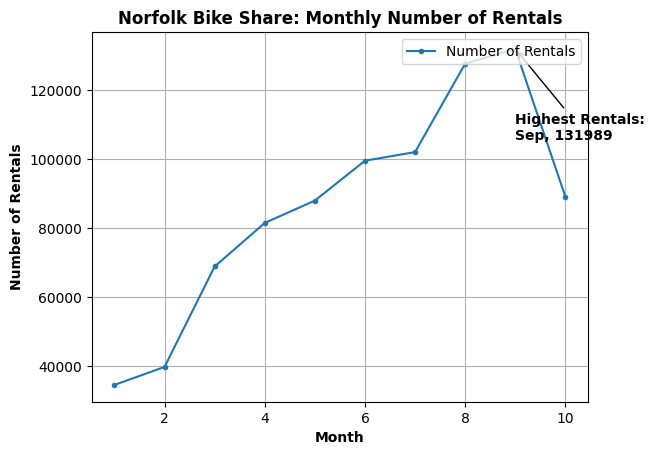

In [16]:
# code to answer the question
#How does the number of rentals change from month to month throughout the year?
import matplotlib.pyplot as plt

starting_date= "Starting Date"
bike[starting_date]=pd.to_datetime(bike[starting_date])
bike["month"]= bike[starting_date].dt.month
monthly_rentals= bike.groupby("month").size()
max_month= monthly_rentals.idxmax()
max_rentals=monthly_rentals.max()

month_names= {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

plt.style.use('default')
fig, ax= plt.subplots()

ax.plot(
    monthly_rentals.index, monthly_rentals.values, 
    label= "Number of Rentals", marker= '.'
    )

ax.set_title("Norfolk Bike Share: Monthly Number of Rentals", 
             fontweight= 'bold')
ax.set_xlabel("Month", fontweight= 'bold')
ax.set_ylabel("Number of Rentals", fontweight= 'bold')
ax.legend(loc= 'upper right')
ax.grid()

ax.annotate(
    f"Highest Rentals:\n{month_names[max_month]}, {max_rentals}",
    xy=(max_month, max_rentals),
    xytext= (max_month, max_rentals*0.8),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize= 10,
    fontweight= 'bold'

)
plt.show()

#### Question 2:

**Your question goes here**

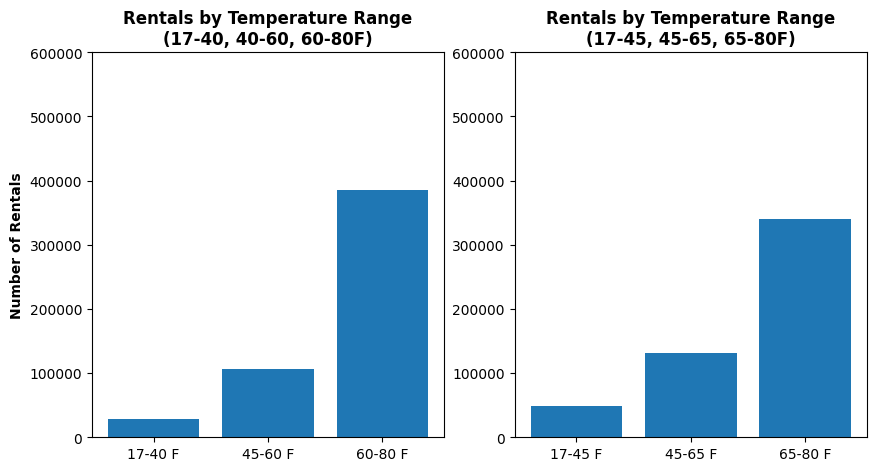

In [17]:
# code to answer the question
#How does the number of rentals vary across different temperature ranges?

import matplotlib.pyplot as plt 

temp_column= "weather_Average Temperature"
count_17_40= ((bike[temp_column]>= 17)& (bike[temp_column]< 40)).sum()
count_40_60= ((bike[temp_column]>= 40)& (bike[temp_column]< 60)).sum()
count_60_80= ((bike[temp_column]>= 60)& (bike[temp_column]<= 80)).sum()

left_label= ['17-40 F', '45-60 F', '60-80 F']
left_counts= [count_17_40, count_40_60, count_60_80]

count_17_45= ((bike[temp_column]>= 17)& (bike[temp_column]< 45)).sum()
count_45_65= ((bike[temp_column]>= 45)& (bike[temp_column]< 65)).sum()
count_65_80= ((bike[temp_column]>= 65)& (bike[temp_column]<= 80)).sum()

right_label= ['17-45 F', '45-65 F', '65-80 F']
right_counts= [count_17_45, count_45_65, count_65_80]

plt.style.use('default')
fig, (ax1, ax2)= plt.subplots(1, 2, figsize=(10, 5))

ax1.bar(left_label, left_counts)
ax1.set_title("Rentals by Temperature Range\n(17-40, 40-60, 60-80F)", fontweight='bold')
ax1.set_ylabel("Number of Rentals", fontweight= 'bold')
ax1.set_ylim([0, 600000])

ax2.bar(right_label, right_counts)
ax2.set_title("Rentals by Temperature Range\n(17-45, 45-65, 65-80F)", fontweight='bold')
ax2.set_ylim([0, 600000])

plt.show()

#### Question 3:

**Your question goes here**

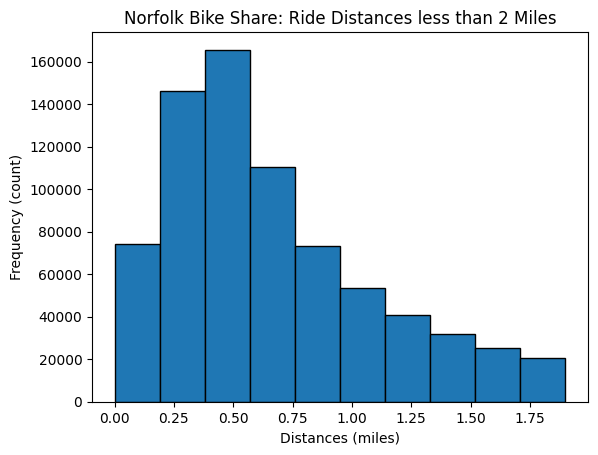

In [18]:
# code to answer the question
#How frequently do rentals occur when the distance traveled is less than 2 miles?
import matplotlib.pyplot as plt

distance_column= "Trip Distance (miles)"
short_trip= bike[bike[distance_column]<2]

fig, ax = plt.subplots()

ax.hist(short_trip[distance_column], edgecolor= 'black')

ax.set_title("Norfolk Bike Share: Ride Distances less than 2 Miles")
ax.set_xlabel("Distances (miles)")
ax.set_ylabel("Frequency (count)")

plt.show()

#### Creating a Plotly Graph

In [19]:
# code to create the plotly graph
import plotly.express as px 
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

starting_date= "Starting Date"
bike[starting_date]= pd.to_datetime(bike[starting_date])

bike["month"]= bike[starting_date].dt.month

monthly_rentals= bike.groupby("month").size()
max_month= monthly_rentals.idxmax()
max_rentals= monthly_rentals.max()

month_names= {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

fig= px.line(
    x=monthly_rentals.index,
    y=monthly_rentals,
    markers=True,)

fig.update_layout(
    title= "Norfolk Bike Share: Monthly Number of Rentals",
    xaxis_title= "Month",
    yaxis_title= "Number of Rentals",
    showlegend= False
)

fig.add_annotation(
    x=max_month,
    y=max_rentals, 
    text=f"<b>Highest Rentals:<br>{month_names[max_month]}, {max_rentals}",
    showarrow=True, 
    arrowhead=2,
    ax=40,
    ay=-40,
)
fig.show()


#### Question 5:

**Creative Exploration- What is the average monthly precipitation and the highest month of precipitation with the specific number of precipitation shown?**

In [20]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

starting_date= "Starting Date"
bike[starting_date]= pd.to_datetime(bike[starting_date])

bike["month"]= bike[starting_date].dt.month

bike["weather_Precipitation"]=bike["weather_Precipitation"].dropna()
avg_precip= bike.groupby("month")["weather_Precipitation"].mean()

max_month= avg_precip.idxmax()
max_precip= avg_precip.max()

month_names= {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

fig= px.line(
    x=avg_precip.index,
    y=avg_precip,
    markers=True,)

fig.update_layout(
    title= "Norfolk Bike Share: Monthly Precipitation",
    xaxis_title= "Month",
    yaxis_title= "Precipitation",
    legend_title= "Avg Precip (in)"
)

fig.add_annotation(
    x=max_month,
    y=max_precip, 
    text=f"<b>Highest Precipitation:<br>{month_names[max_month]}, {max_precip}",
    showarrow=True, 
    arrowhead=2,
    ax=40,
    ay=-40,
)
fig.show()

Final Question- Is there a measurable correlation between cloud coverage and vehicle usage?  For instance, is affinity for vehicle usage higher or lower at a specific level of cloud coverage? If we had a column measuring cloud coverage, we could filter the data and separate this by cloud coverage level, adding the total number of rentals at each level of cloud coverage in order to determine a measurable result.  I would be interested to see if users are more inclined to use these vehicles at a higher level of cloud coverage, rather than on a sunny day.  This is relevant to the dataset, because we have the total number of rentals, but since we don't have specific cloud coverage (as a percent), we cannot draw a conclusion without additional data.